In [1]:
import polars as pl

df = pl.read_csv(
    "../data/lehner_dataset.txt",
    separator="\t",
    null_values="NA",  # Na interpeted as null
    infer_schema_length=10000
)

print(df.collect_schema())

Schema({'domain_ID': String, 'uniprot_ID': String, 'aa_seq': String, 'wt_aa': String, 'position': Int64, 'mut_aa': String, 'STOP': Boolean, 'input_count_rep1': Int64, 'input_count_rep2': Int64, 'input_count_rep3': Int64, 'output_count_rep1': Int64, 'output_count_rep2': Int64, 'output_count_rep3': Int64, 'mean_input_count': Float64, 'fitness': Float64, 'fitness_sigma': Float64, 'normalized_fitness': Float64, 'normalized_fitness_sigma': Float64, 'quality_rank': Int64})


1. **`domain_ID`** – identifikátor domény proteinu, např. konkrétní segment v rámci celého proteinu.
2. **`uniprot_ID`** – unikátní ID proteinu podle databáze UniProt.
3. **`aa_seq`** – sekvence aminokyselin daného proteinu/domény.
4. **`wt_aa`** – „wild-type“ aminokyselina, tedy originální aminokyselina na dané pozici před mutací.
5. **`position`** – pozice aminokyseliny v sekvenci (indexace obvykle začíná od 1).
6. **`mut_aa`** – aminokyselina, která byla zavedena místo wild-type (mutovaná).
7. **`STOP`** – značí, zda mutace vede k stop-kodon (předčasnému ukončení proteinu).

---

8.–10. **`input_count_rep1`, `input_count_rep2`, `input_count_rep3`** – počty přečtení (read counts) mutace ve vstupní knihovně pro tři replikáty experimentu.
11.–13. **`output_count_rep1`, `output_count_rep2`, `output_count_rep3`** – počty přečtení mutace po selekci, tzn. kolik přežilo/aktivně fungovalo.

---

14. **`mean_input_count`** – průměr počtu vstupů přes replikáty, užitečné pro normalizaci.
15. **`fitness`** – odhad „fitness“ mutace, např. jak moc mutace ovlivňuje funkci proteinu (často log ratio output/input) (můžeš podle ní vážit loss funkci → čím menší sigma, tím víc věříš danému datu.).
16. **`fitness_sigma`** – chyba nebo odchylka od fitness měření (standard deviation).
17. **`normalized_fitness`** – fitness upravená pro porovnání mezi různými mutacemi/proteiny.
18. **`normalized_fitness_sigma`** – odchylka normalizované fitness (můžeš podle ní vážit loss funkci → čím menší sigma, tím víc věříš danému datu..
19. **`quality_rank`** – hodnocení kvality datové řádky, např. A/B/C podle spolehlivosti měření.

---

Jednoduše řečeno: **každý řádek odpovídá jedné mutaci** proteinu/domény a obsahuje informace o pozici, typu mutace a její experimentálně měřenou účinnost/stabilitu.



In [5]:
df

domain_ID,uniprot_ID,aa_seq,wt_aa,position,mut_aa,STOP,input_count_rep1,input_count_rep2,input_count_rep3,output_count_rep1,output_count_rep2,output_count_rep3,mean_input_count,fitness,fitness_sigma,normalized_fitness,normalized_fitness_sigma,quality_rank
str,str,str,str,i64,str,bool,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,i64
"""A0A2R8Y422_PF00240_2""","""A0A2R8Y422""","""*IFVKTLMGKTITLEVELSDTIDNVKAKIQ…","""Q""",2,"""*""",true,118,113,62,10,29,2,97.66667,0.030945,0.014885,-0.81905,0.208478,339
"""A0A2R8Y422_PF00240_2""","""A0A2R8Y422""","""AIFVKTLMGKTITLEVELSDTIDNVKAKIQ…","""Q""",2,"""A""",false,219,277,217,86,225,137,237.6667,0.069376,0.006673,-0.28079,0.093461,339
"""A0A2R8Y422_PF00240_2""","""A0A2R8Y422""","""CIFVKTLMGKTITLEVELSDTIDNVKAKIQ…","""Q""",2,"""C""",false,706,726,459,768,507,616,630.3333,0.082052,0.004141,-0.10325,0.057995,339
"""A0A2R8Y422_PF00240_2""","""A0A2R8Y422""","""DIFVKTLMGKTITLEVELSDTIDNVKAKIQ…","""Q""",2,"""D""",false,407,431,323,508,159,111,387.0,0.071003,0.005162,-0.258003,0.072296,339
"""A0A2R8Y422_PF00240_2""","""A0A2R8Y422""","""EIFVKTLMGKTITLEVELSDTIDNVKAKIQ…","""Q""",2,"""E""",false,37,56,37,201,102,95,43.33333,0.1163261,0.012085,0.376783,0.169263,339
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Q9Y6V0_PF05715_1058""","""Q9Y6V0""","""TWPLCKTELNIGSKDPPNFNTCTECKNQVC…","""C""",1059,"""W""",false,118,121,83,13,47,4,107.3333,0.028085,0.013317,-0.903822,0.15048,380
"""Q9Y6V0_PF05715_1058""","""Q9Y6V0""","""TYPLCKTELNIGSKDPPNFNTCTECKNQVC…","""C""",1059,"""Y""",false,177,168,126,12,6,29,157.0,0.006343,0.013753,-1.149495,0.155403,380
"""Q9Y6V0_PF05715_1058""","""Q9Y6V0""","""VCPLCKTELNIGSKDPPNFNTCTECKNQVC…","""T""",1058,"""V""",false,20,19,23,46,43,8,20.66667,0.09024,0.021806,-0.201507,0.246396,380


In [3]:
import polars as pl
import requests
from io import StringIO
from tqdm import tqdm  # For progress bars


def fetch_uniprot_sequence(uniprot_id: str):
    """Fetch the original protein sequence from UniProt"""
    url = f"https://rest.uniprot.org/uniprotkb/{uniprot_id}.fasta"
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()

        if uniprot_id == "A2R8Y422":
            print(response.text)

        # Parse the FASTA file to extract the sequence
        fasta_data = StringIO(response.text)
        fasta_data.readline()  # skip header
        sequence = "".join(line.strip() for line in fasta_data)
        return sequence
    except requests.exceptions.RequestException as e:
        print(f"\nError fetching sequence for {uniprot_id}: {str(e)}")
        return None


df_with_parent = df

# Get unique UniProt IDs
uniprot_ids = df_with_parent["uniprot_ID"].unique().to_list()
print(f"Found {len(uniprot_ids)} unique UniProt IDs to process")

# Create a dictionary to store sequences
sequences = {}
failed_ids = []

# Fetch sequences for each UniProt ID with progress bar
print("\nDownloading sequences from UniProt:")
for uniprot_id in tqdm(uniprot_ids, desc="Progress"):
    if uniprot_id is None:
        continue
    sequence = fetch_uniprot_sequence(uniprot_id)

    if sequence or sequences == "":
        sequences[uniprot_id] = sequence
    else:
        sequences[uniprot_id] = None
        failed_ids.append(uniprot_id)

# Add original sequence column to dataframe
alpha = 0.2
df_with_parent = df_with_parent.with_columns(
    pl.col("uniprot_ID").replace(sequences).alias("original_sequence"),
    (2 / (1 + pl.exp(-alpha * pl.col("normalized_fitness"))) - 1).alias("normalized_fitness_training")
)

print("\nProcessing complete!")
print(f"Successfully retrieved {len(sequences)} sequences")
print(f"Failed to retrieve {len(failed_ids)} sequences")
if failed_ids:
    print("Failed IDs:", ", ".join(failed_ids))

df_with_parent_original = df_with_parent.clone()

df_with_parent_original.write_csv("lehner_dataset_with_sequences.csv")


Found 434 unique UniProt IDs to process



Progress:   2%|▏         | 9/434 [00:02<01:43,  4.11it/s]


KeyboardInterrupt: 

In [3]:
import polars as pl
import numpy as np

df_with_parent_original = pl.read_csv(
    "lehner_dataset_with_sequences.csv",
    separator=",",
    null_values="NA",
    infer_schema_length=10000
)

# https://www.uniprot.org/uniparc

# missing sequences : HHH-rd1-0142, EEHEE-rd3-0037, EHEE-rd1-0882


mapping = {
    "P61960": "MSKVSFKITLTSDPRLPYKVLSVPESTPFTAVLKFAAEEFKVPAATSAIITNDGIGINPAQTAGNVFLKHGSELRIIPRDRVGSC",
    # https://www.uniprot.org/uniparc/UPI00000041DB/entry
    "Q3SY89": "MAAGSTTLRAVGKLQVRLATKTEPKKLEKYLQKLSALPMTADILAETGIRKTVKRLRKHQHVGDFARDLAARWKKLVLVDRNTGPDPQDPEESASRQRFGEALQEREKAWGFPENATAPRSPSHSPEHRRTARRTPPGQQRPHPRSPSREPRAERKRPRMAPADSGPHRDPPTRTAPLPMPEGPEPAVPGEQPGRGHAHAAQGGPLLGQGCQGQPQGEAVGSHSKGHKSSRGASAQKSPPVQESQSERLQAAGADSAGPKTVPSHVFSELWDPSEAWMQANYDLLSAFEAMTSQANPEALSAPTLQEEAAFPGRRVNAKMPVYSGSRPACQLQVPTLRQQCLRVPRNNPDALGDVEGVPYSVLEPVLEGWTPDQPYRTEKDNAALARETDELWRIHCLQDFKEEKPQEHESWRELYLRLRDAREQRLRVVTTKIRSARENKPSGRQTKMICFNSVAKTPYDASRRQEKSAGAADPGNGEMEPAPKPAGSSQAPSGLGDGDGGSVSGGGSSNRHAAPADKTRKQAAKKVAPLMAKAIRDYKGRFSRR",
    # https://www.uniprot.org/uniparc/UPI0000366CBD/entry
    "A0A2R8Y422": "MQIFVKTLMGKTITLEVELSDTIDNVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYNIQKESTLHLVLRLRGGAKKRKKKSYTTPRKNKHKRKKVKLALLKYYKVDENGKISCLHRECPSDECGAGVFMASHFDRHYCGKCCLTYCFNKPEDK",
    # https://www.uniprot.org/uniparc/UPI000006FE7A/entry
    "P61086": "MANIAVQRIKREFKEVLKSEETSKNQIKVDLVDENFTELRGEIAGPPDTPYEGGRYQLEIKIPETYPFNPPKVRFITKIWHPNISSVTGAICLDILKDQWAAAMTLRTVLLSLQALLAAAEPDDPQDAVVANQYKQNPEMFKQTARLWAHVYAGAPVSSPEYTKKIENLCAMGFDRNAVIVALSSKSWDVETATELLLSN",    #https://www.uniprot.org/uniparc/UPI0000003FF1/entry
    "A1X283": "MPPRRSIVEVKVLDVQKRRVPNKHYVYIIRVTWSSGSTEAIYRRYSKFFDLQMQMLDKFPMEGGQKDPKQRIIPFLPGKILFRRSHIRDVAVKRLIPIDEYCKALIQLPPYISQCDEVLQFFETRPEDLNPPKEEHIGKKKSGGDQTSVDPMVLEQYVVVANYQKQESSEISLSVGQVVDIIEKNESGWWFVSTAEEQGWVPATCLEGQDGVQDEFSLQPEEEEKYTVIYPYTARDQDEMNLERGAVVEVIQKNLEGWWKIRYQGKEGWAPASYLKKNSGEPLPPKPGPGSPSHPGALDLDGVSRQQNAVGREKELLSSQRDGRFEGRPVPDGDAKQRSPKMRQRPPPRRDMTIPRGLNLPKPPIPPQVEEEYYTIAEFQTTIPDGISFQAGLKVEVIEKNLSGWWYIQIEDKEGWAPATFIDKYKKTSNASRPNFLAPLPHEVTQLRLGEAAALENNTGSEATGPSRPLPDAPHGVMDSGLPWSKDWKGSKDVLRKASSDMSASAGYEEISDPDMEEKPSLPPRKESIIKSEGELLERERERQRTEQLRGPTPKPPGVILPMMPAKHIPPARDSRRPEPKPDKSRLFQLKNDMGLECGHKVLAKEVKKPNLRPISKSKTDLPEEKPDATPQNPFLKSRPQVRPKPAPSPKTEPPQGEDQVDICNLRSKLRPAKSQDKSLLDGEGPQAVGGQDVAFSRSFLPGEGPGRAQDRTGKQDGLSPKEISCRAPPRPAKTTDPVSKSVPVPLQEAPQQRPVVPPRRPPPPKKTSSSSRPLPEVRGPQCEGHESRAAPTPGRALLVPPKAKPFLSNSLGGQDDTRGKGSLGPWGTGKIGENREKAAAASVPNADGLKDSLYVAVADFEGDKDTSSFQEGTVFEVREKNSSGWWFCQVLSGAPSWEGWIPSNYLRKKP", # https://www.uniprot.org/uniparc/UPI000020C12E/entry

    "O95718":"MSSDDRHLGSSCGSFIKTEPSSPSSGIDALSHHSPSGSSDASGGFGLALGTHANGLDSPPMFAGAGLGGTPCRKSYEDCASGIMEDSAIKCEYMLNAIPKRLCLVCGDIASGYHYGVASCEACKAFFKRTIQGNIEYSCPATNECEITKRRRKSCQACRFMKCLKVGMLKEGVRLDRVRGGRQKYKRRLDSESSPYLSLQISPPAKKPLTKIVSYLLVAEPDKLYAMPPPGMPEGDIKALTTLCDLADRELVVIIGWAKHIPGFSSLSLGDQMSLLQSAWMEILILGIVYRSLPYDDKLVYAEDYIMDEEHSRLAGLLELYRAILQLVRRYKKLKVEKEEFVTLKALALANSDSMYIEDLEAVQKLQDLLHEALQDYELSQRHEEPWRTGKLLLTLPLLRQTAAKAVQHFYSVKLQGKVPMHKLFLEMLEAKAWARADSLQEWRPLEQVPSPLHRATKRQHVHFLTPLPPPPSVAWVGTAQAGYHLEVFLPQRAGWPRAA" # https://www.uniprot.org/uniparc/UPI000012A17F/entry

}

alpha = 0.2
df_with_parent_original = df_with_parent_original.with_columns(
    (2 / (1 + np.exp(-alpha * pl.col("normalized_fitness"))) - 1).alias("normalized_fitness_training_sigmoid"),
    (pl.col("normalized_fitness") / 8.0).tanh().alias("normalized_fitness_training_tanh"),
    pl.when(pl.col("normalized_fitness") <= 0)
    .then(
        # Pro záporné: jiný alpha (např. 0.15 pro více prostoru kolem nuly)
        (2 / (1 + (-0.15 * pl.col("normalized_fitness")).exp()) - 1) * 0.5 - 0.5
    )
    .otherwise(
        # Pro kladné: jiný alpha (např. 0.3 pro méně prostoru)
        ((2 / (1 + (-0.3 * pl.col("normalized_fitness")).exp()) - 1) + 1) * 0.5
    )
    .alias("normalized_fitness_asymmetric"),

    pl.when(pl.col("uniprot_ID").is_in(list(mapping.keys())))
    .then(pl.col("uniprot_ID").replace(mapping))
    .otherwise(pl.col("original_sequence"))
    .alias("original_sequence")

)

df_with_parent_original.write_csv("lehner_dataset_with_sequences.csv")

df_with_parent_original.filter(pl.col("original_sequence").is_null())


domain_ID,uniprot_ID,aa_seq,wt_aa,position,mut_aa,STOP,input_count_rep1,input_count_rep2,input_count_rep3,output_count_rep1,output_count_rep2,output_count_rep3,mean_input_count,fitness,fitness_sigma,normalized_fitness,normalized_fitness_sigma,quality_rank,original_sequence,normalized_fitness_training,normalized_fitness_training_sigmoid,normalized_fitness_training_tanh,normalized_fitness_asymmetric
str,str,str,str,i64,str,bool,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,i64,str,f64,f64,f64,f64
"""EEHEE-rd3-0037_rockdoms_1""","""EEHEE-rd3-0037""","""*TIKVNGQEYTVPLSPEQAAKAAKKRWPDY…","""T""",1,"""*""",true,15,22,16,2,0,0,17.66667,0.063262,0.04179,-1.103645,0.4299,275,null,-0.109919,-0.109919,-0.137087,-0.541292
"""EEHEE-rd3-0037_rockdoms_1""","""EEHEE-rd3-0037""","""ATIKVNGQEYTVPLSPEQAAKAAKKRWPDY…","""T""",1,"""A""",false,114,80,80,103,57,70,91.33333,0.1244015,0.007611,-0.474702,0.078296,275,null,-0.047435,-0.047435,-0.059268,-0.517794
"""EEHEE-rd3-0037_rockdoms_1""","""EEHEE-rd3-0037""","""CTIKVNGQEYTVPLSPEQAAKAAKKRWPDY…","""T""",1,"""C""",false,33,16,28,69,14,58,25.66667,0.1533467,0.010816,-0.17694,0.111262,275,null,-0.017692,-0.017692,-0.022114,-0.506635
"""EEHEE-rd3-0037_rockdoms_1""","""EEHEE-rd3-0037""","""DTIKVNGQEYTVPLSPEQAAKAAKKRWPDY…","""T""",1,"""D""",false,63,27,34,10,3,7,41.33333,0.067923,0.015044,-1.0557,0.154757,275,null,-0.10518,-0.10518,-0.131202,-0.539506
"""EEHEE-rd3-0037_rockdoms_1""","""EEHEE-rd3-0037""","""ETIKVNGQEYTVPLSPEQAAKAAKKRWPDY…","""T""",1,"""E""",false,15,10,17,1,0,12,14.0,0.1056807,0.021483,-0.667285,0.221002,275,null,-0.06663,-0.06663,-0.083218,-0.525002
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""HHH-rd1-0142_rockdoms_1""","""HHH-rd1-0142""","""SKWEEIAERLREEFNINPEEAREAVEKAGG…","""R""",1,"""S""",false,119,99,99,578,700,341,105.6667,0.1818181,0.00657,-0.034943,0.087902,235,null,-0.003494,-0.003494,-0.004368,-0.50131
"""HHH-rd1-0142_rockdoms_1""","""HHH-rd1-0142""","""TKWEEIAERLREEFNINPEEAREAVEKAGG…","""R""",1,"""T""",false,61,14,92,665,78,485,55.66667,0.1978041,0.007958,0.178925,0.106461,235,null,0.017891,0.017891,0.022362,0.513416
"""HHH-rd1-0142_rockdoms_1""","""HHH-rd1-0142""","""VKWEEIAERLREEFNINPEEAREAVEKAGG…","""R""",1,"""V""",false,302,293,281,1633,1544,1597,292.0,0.1875909,0.005058,0.042288,0.067671,235,null,0.004229,0.004229,0.005286,0.503172


In [4]:
df_with_parent = pl.read_csv(
    "lehner_dataset_with_sequences.csv",
    separator=",",
    null_values="NA",
    infer_schema_length=10000
)

df_with_parent

domain_ID,uniprot_ID,aa_seq,wt_aa,position,mut_aa,STOP,input_count_rep1,input_count_rep2,input_count_rep3,output_count_rep1,output_count_rep2,output_count_rep3,mean_input_count,fitness,fitness_sigma,normalized_fitness,normalized_fitness_sigma,quality_rank,original_sequence,normalized_fitness_training,normalized_fitness_training_sigmoid,normalized_fitness_training_tanh,normalized_fitness_asymmetric
str,str,str,str,i64,str,bool,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,i64,str,f64,f64,f64,f64
"""A0A2R8Y422_PF00240_2""","""A0A2R8Y422""","""*IFVKTLMGKTITLEVELSDTIDNVKAKIQ…","""Q""",2,"""*""",true,118,113,62,10,29,2,97.66667,0.030945,0.014885,-0.81905,0.208478,339,"""MQIFVKTLMGKTITLEVELSDTIDNVKAKI…",-0.081722,-0.081722,-0.102025,-0.530676
"""A0A2R8Y422_PF00240_2""","""A0A2R8Y422""","""AIFVKTLMGKTITLEVELSDTIDNVKAKIQ…","""Q""",2,"""A""",false,219,277,217,86,225,137,237.6667,0.069376,0.006673,-0.28079,0.093461,339,"""MQIFVKTLMGKTITLEVELSDTIDNVKAKI…",-0.028072,-0.028072,-0.035084,-0.510528
"""A0A2R8Y422_PF00240_2""","""A0A2R8Y422""","""CIFVKTLMGKTITLEVELSDTIDNVKAKIQ…","""Q""",2,"""C""",false,706,726,459,768,507,616,630.3333,0.082052,0.004141,-0.10325,0.057995,339,"""MQIFVKTLMGKTITLEVELSDTIDNVKAKI…",-0.010325,-0.010325,-0.012906,-0.503872
"""A0A2R8Y422_PF00240_2""","""A0A2R8Y422""","""DIFVKTLMGKTITLEVELSDTIDNVKAKIQ…","""Q""",2,"""D""",false,407,431,323,508,159,111,387.0,0.071003,0.005162,-0.258003,0.072296,339,"""MQIFVKTLMGKTITLEVELSDTIDNVKAKI…",-0.025795,-0.025795,-0.032239,-0.509674
"""A0A2R8Y422_PF00240_2""","""A0A2R8Y422""","""EIFVKTLMGKTITLEVELSDTIDNVKAKIQ…","""Q""",2,"""E""",false,37,56,37,201,102,95,43.33333,0.1163261,0.012085,0.376783,0.169263,339,"""MQIFVKTLMGKTITLEVELSDTIDNVKAKI…",0.03766,0.03766,0.047063,0.528229
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Q9Y6V0_PF05715_1058""","""Q9Y6V0""","""TWPLCKTELNIGSKDPPNFNTCTECKNQVC…","""C""",1059,"""W""",false,118,121,83,13,47,4,107.3333,0.028085,0.013317,-0.903822,0.15048,380,"""MGNEASLEGEGLPEGLAAAAAAGGGASGAG…",-0.090137,-0.090137,-0.112499,-0.533841
"""Q9Y6V0_PF05715_1058""","""Q9Y6V0""","""TYPLCKTELNIGSKDPPNFNTCTECKNQVC…","""C""",1059,"""Y""",false,177,168,126,12,6,29,157.0,0.006343,0.013753,-1.149495,0.155403,380,"""MGNEASLEGEGLPEGLAAAAAAGGGASGAG…",-0.114446,-0.114446,-0.142706,-0.543
"""Q9Y6V0_PF05715_1058""","""Q9Y6V0""","""VCPLCKTELNIGSKDPPNFNTCTECKNQVC…","""T""",1058,"""V""",false,20,19,23,46,43,8,20.66667,0.09024,0.021806,-0.201507,0.246396,380,"""MGNEASLEGEGLPEGLAAAAAAGGGASGAG…",-0.020148,-0.020148,-0.025183,-0.507556


In [5]:
df_with_parent_original = df_with_parent

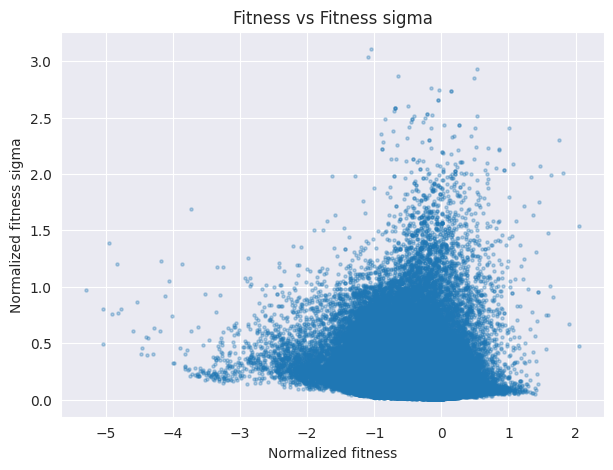

In [6]:
import matplotlib.pyplot as plt

# Scatter plot
plt.figure(figsize=(7, 5))
plt.scatter(
    df_with_parent_original["normalized_fitness"].to_numpy(),
    df_with_parent_original["normalized_fitness_sigma"].to_numpy(),
    alpha=0.3, s=5
)
plt.xlabel("Normalized fitness")
plt.ylabel("Normalized fitness sigma")
plt.title("Fitness vs Fitness sigma")
plt.show()


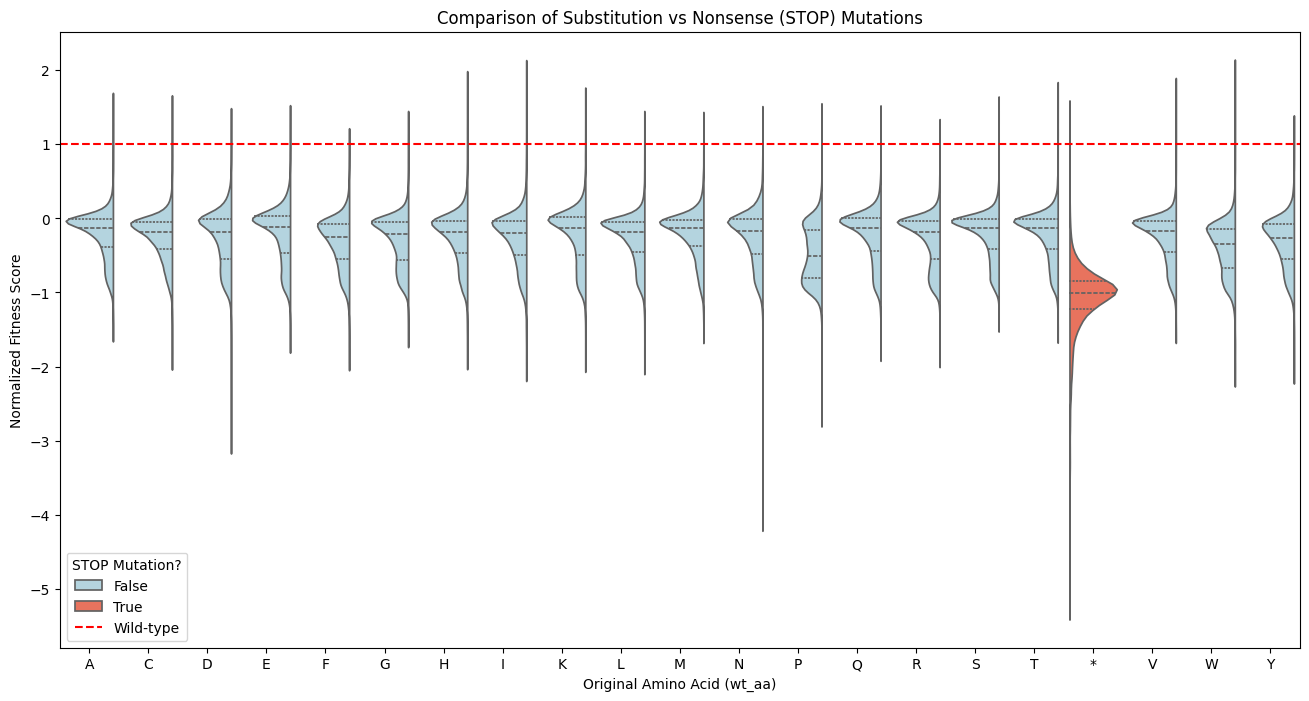

In [16]:
plt.figure(figsize=(16, 8))
sns.violinplot(
    data=df_with_parent_original.to_pandas(),
    x="mut_aa",
    y="normalized_fitness",
    hue="STOP",
    split=True,
    palette={True: "tomato", False: "lightblue"},
    inner="quartile"
)
plt.axhline(1.0, color="red", linestyle="--", label="Wild-type")
plt.title("Comparison of Substitution vs Nonsense (STOP) Mutations")
plt.xlabel("Original Amino Acid (wt_aa)")
plt.ylabel("Normalized Fitness Score")
plt.legend(title="STOP Mutation?")
plt.show()